In [ ]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/personalNotes.git

# Move into repository
%cd /content/personalNotes

# Move into Chapter 1 folder
%cd notebooks/04_numpy

Why do Data Scientists obsess over NumPy? It comes down to three pillars: **Speed**, **Memory**, and **Convenience**. 
Python lists are arrays of pointers to scattered objects in memory, requiring type-checking on every operation. NumPy arrays store raw, homogeneous data in contiguous memory blocks and use pre-compiled C-code for **vectorization**, eliminating Python loop overhead.

### 📊 Diagram: Memory Layout
```text
Python List (Scattered & Heavy)
[ ptr ] -> [ int obj (28 bytes) ]
[ ptr ] -> [ int obj (28 bytes) ]
[ ptr ] -> [ int obj (28 bytes) ]

NumPy Array (Contiguous & Lightweight)
[ 4 bytes | 4 bytes | 4 bytes ] (int32)
```

### ⚠️ Common Mistake
Using `sys.getsizeof(list)` to measure a Python list's memory. This only returns the size of the list object itself (the array of pointers), **not** the memory of the individual elements inside it! You must sum the sizes of all elements to get the true memory footprint.

### 🏋️ Practice Tasks (Easy)
1. Create a Python list of numbers from 0 to 999,999. Measure its true memory size in MB.
2. Create a NumPy array of the same numbers using `dtype=np.int32`. Measure its memory in MB.
3. Compare the two values. How many times smaller is the NumPy array?

### 🏋️ Practice Tasks (Medium)
4. Write a Python `for` loop to square every element in a list of 1 million numbers. Time it.
5. Use NumPy vectorization (`arr ** 2`) to do the same. Time it.
6. Calculate the speedup factor.

### 🏋️ Practice Tasks (Hard)
7. Create two lists of 5 million random floats. Add them element-wise using a list comprehension.
8. Do the same using NumPy arrays (`dtype=np.float32`).
9. Calculate the memory saved by using `float32` instead of Python's default `float` (which is `float64`).

### 🚀 Mini Challenge
Write a single line of NumPy code to create an array of 10 million elements that takes exactly **10 MB** of memory. What `dtype` did you use?

### 🎤 Interview Question
**Q:** Why is NumPy faster than Python lists, and what is the trade-off?
**A:** NumPy is faster because it uses **contiguous memory allocation** (better CPU cache locality) and **vectorized C-level operations** (no Python loop overhead). The trade-off is that NumPy arrays have a **fixed size** at creation and require **homogeneous data types**, whereas Python lists are dynamic and can hold mixed types.

### 🌍 Real World Use Case
When training a Deep Learning model on 100,000 images, loading them into Python lists will crash your RAM. Converting them to a NumPy array of `float32` reduces memory usage by 75% and speeds up matrix multiplications by 50x.

### 💡 Fun Fact
NumPy can add 10 million integers in ~0.01 seconds. That is faster than the blink of a human eye (~0.1 seconds)!


In [1]:
import numpy as np
import sys
import time

# ==========================================
# 💻 EXAMPLE: Speed & Memory Benchmark
# ==========================================

n = 10_000_000

# --- MEMORY COMPARISON ---
py_list = list(range(n))
# True memory of list = size of list object + size of all int objects
true_list_mem = sys.getsizeof(py_list) + sum(sys.getsizeof(i) for i in py_list)

np_arr = np.arange(n, dtype=np.int32)
np_mem = np_arr.nbytes

print(f"📋 Python List Memory: {true_list_mem / 1e6:.2f} MB")
print(f"🔢 NumPy int32 Memory: {np_mem / 1e6:.2f} MB")
print(f"💾 Memory Saved: {true_list_mem / np_mem:.1f}x smaller!\n")

# --- SPEED COMPARISON ---
# Python List
start = time.time()
py_sq = [x**2 for x in py_list[:1000000]] # Using 1M for speed
list_time = time.time() - start

# NumPy
start = time.time()
np_sq = np_arr[:1000000] ** 2
np_time = time.time() - start

print(f"⏱️ Python List Time: {list_time:.4f} s")
print(f"⏱️ NumPy Time:       {np_time:.6f} s")
print(f"⚡ Speedup:          {list_time/np_time:.1f}x faster!")


📋 Python List Memory: 360.00 MB
🔢 NumPy int32 Memory: 40.00 MB
💾 Memory Saved: 9.0x smaller!

⏱️ Python List Time: 0.0670 s
⏱️ NumPy Time:       0.001000 s
⚡ Speedup:          67.0x faster!


# 🎯 Concept 2: Advanced Indexing (Fancy & Boolean)

# 🎯 Concept 2: Advanced Indexing (Fancy & Boolean)


Beyond basic slicing (`start:stop`), NumPy offers advanced data querying to extract exact patterns from your matrices.

### 🎩 1. Fancy Indexing
Instead of slicing a continuous block, you pass a *list* (or array) of specific indices to extract non-sequential rows or columns.
* **Syntax:** `array[:, [col_index1, col_index2]]`
* ⚠️ **Crucial Note:** Unlike standard slicing (which returns a view), Fancy Indexing returns a **COPY** of the data. 

### 🎭 2. Boolean Indexing (Masking)
This is the ultimate data filtering tool. You apply a logical condition to generate an array of `True`/`False` values, which acts as a "mask" to extract only the data you want.
* **Syntax:** Use `&` (AND), `|` (OR), and `~` (NOT) for multiple conditions.

### 📊 Diagram: Boolean Masking
```text
Array:       [[12, 45, 23],
              [67,  8, 89],
              [56, 34,  2]]

Condition:   arr > 30
Mask:        [[False, True, False],
              [True, False, True],
              [True, True, False]]

Result:      [45, 67, 89, 56, 34] (Flattened 1D array)
```

### ⚠️ Common Mistake
Using Python's logical operators `and`, `or`, `not` on NumPy arrays.

❌ `arr[arr > 50 and arr < 80]` -> **ValueError!**

✅ `arr[(arr > 50) & (arr < 80)]` -> **Correct!** (Always use `&`, `|`, `~` and wrap conditions in parentheses).

In [2]:
# ==========================================
# 💻 EXAMPLE: Advanced Indexing
# ==========================================
arr = np.arange(1, 37).reshape(6, 6)

# Fancy Indexing
print("🎩 Fancy Indexing (Diagonal):")
print(arr[np.arange(6), np.arange(6)])

# Boolean Indexing
print("\n🎭 Boolean Indexing (> 30):")
print(arr[arr > 30])

# Combined Conditions
print("\n🔗 Combined (Even AND > 20):")
print(arr[(arr > 20) & (arr % 2 == 0)])

# Mini Challenge Solution: Reverse rows
print("\n🔄 Reversed Rows:")
print(arr[::-1, :])


🎩 Fancy Indexing (Diagonal):
[ 1  8 15 22 29 36]

🎭 Boolean Indexing (> 30):
[31 32 33 34 35 36]

🔗 Combined (Even AND > 20):
[22 24 26 28 30 32 34 36]

🔄 Reversed Rows:
[[31 32 33 34 35 36]
 [25 26 27 28 29 30]
 [19 20 21 22 23 24]
 [13 14 15 16 17 18]
 [ 7  8  9 10 11 12]
 [ 1  2  3  4  5  6]]


In [8]:
# Create a 6x4 matrix of random integers between 1 and 100
np.random.seed(42)
a = np.random.randint(1, 100, 24).reshape(6, 4)
print("Original 6x4 Array:\n", a)

# ==========================================
# 🎩 FANCY INDEXING
# ==========================================
# Extract ALL rows (:), but ONLY columns at index 0, 2, and 3
print("\nFancy Indexing (Cols 0, 2, 3):\n", a[:, [0, 2, 3]])

# ==========================================
# 🎭 BOOLEAN INDEXING
# ==========================================
print("\nNumbers > 50:\n", a[a > 50])

print("\nEven Numbers:\n", a[a % 2 == 0])

# Using & (AND) for combined conditions
print("\nEven AND > 50:\n", a[(a > 50) & (a % 2 == 0)])

# Using ~ (NOT) to find numbers NOT divisible by 7
print("\nNot divisible by 7:\n", a[~(a % 7 == 0)])

Original 6x4 Array:
 [[52 93 15 72]
 [61 21 83 87]
 [75 75 88 24]
 [ 3 22 53  2]
 [88 30 38  2]
 [64 60 21 33]]

Fancy Indexing (Cols 0, 2, 3):
 [[52 15 72]
 [61 83 87]
 [75 88 24]
 [ 3 53  2]
 [88 38  2]
 [64 21 33]]

Numbers > 50:
 [52 93 72 61 83 87 75 75 88 53 88 64 60]

Even Numbers:
 [52 72 88 24 22  2 88 30 38  2 64 60]

Even AND > 50:
 [52 72 88 88 64 60]

Not divisible by 7:
 [52 93 15 72 61 83 87 75 75 88 24  3 22 53  2 88 30 38  2 64 60 33]


### 🛠️ Practice Tasks: Concept 2
*Create a new code cell and complete the following:*
1. **Fancy Extraction:** Create an 8x8 matrix representing a chessboard. Use Fancy Indexing to extract the 1st, 4th, and 8th rows entirely.
2. **L1 Support Ticket Filter:** Generate a 1D array of 50 random integers (between 5 and 120) representing the resolution time in minutes for technical support tickets. Use Boolean Indexing to extract all tickets that took between 30 and 60 minutes.
3. **Data Cleaning:** From the same ticket array, use the `~` (NOT) operator to isolate and print all outlier tickets that did *not* take exactly 15, 30, or 45 minutes.

### 🏋️ Practice Tasks (Easy)
Given `arr = np.arange(1, 37).reshape(6, 6)`:
1. Extract the 3rd row using standard indexing.
2. Extract all numbers greater than 20.
3. Extract all even numbers.

### 🏋️ Practice Tasks (Medium)
4. Extract the main diagonal (1, 8, 15, 22, 29, 36) using Fancy Indexing.
5. Extract all numbers divisible by 5 AND greater than 10.
6. Replace all prime numbers in the array with `-1`.

### 🏋️ Practice Tasks (Hard)
7. Extract the "border" elements of the 6x6 matrix (first/last row, first/last col).
8. Extract the anti-diagonal (6, 11, 16, 21, 26, 31).
9. Find all numbers where the row index is greater than the column index (lower triangle, excluding diagonal).

### 🚀 Mini Challenge
Without using loops, reverse the rows of a 5x5 matrix so the last row becomes the first. *(Hint: Use slicing `[::-1]`)*.

### 🎤 Interview Question
**Q:** What is the difference between `arr[:, 1:3]` and `arr[:, [1, 3]]`?
**A:** `arr[:, 1:3]` is **slicing**, which returns a **view** (modifying it changes the original array). `arr[:, [1, 3]]` is **fancy indexing**, which returns a **copy** (modifying it does not affect the original).

### 🌍 Real World Use Case
In image processing, Boolean indexing is used to apply a "mask". For example, isolating all pixels in a satellite image where the infrared value > threshold to detect forest fires, and setting the rest to black.

### 💡 Fun Fact
Boolean indexing creates a flattened 1D array because NumPy doesn't know how to preserve the original 2D shape when an arbitrary number of elements are removed!


## 📡 Concept 3: Broadcasting

### 📝 Theory
**Broadcasting** is NumPy's ability to perform arithmetic on arrays of **different shapes**. NumPy virtually "stretches" the smaller array to match the larger array without actually copying data in memory.

### 📊 Diagram: The 2 Rules of Broadcasting
```text
Rule 1: Align shapes from the RIGHT. Pad the smaller shape with 1s on the LEFT.
  (4, 3)
  (   3,)  --> Padded to --> (1, 3)

Rule 2: Dimensions are compatible if they are EQUAL or ONE OF THEM IS 1.
  (4, 3)
  (1, 3)  --> 1 stretches to 4 --> (4, 3) ✅
```

### ⚠️ Common Mistake
Trying to add `(4, 3)` and `(4,)`. 
NumPy pads the right: `(4, 3)` and `(1, 4)`. 
Compare dimensions: 3 vs 4. Neither is 1. **ValueError!** 
To fix it, reshape `(4,)` to `(4, 1)` using `arr.reshape(4, 1)` or `arr[:, np.newaxis]`.



1. Make the two arrays have the same number of dimensions.

If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.
2. Make each dimension of the two arrays the same size.

If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

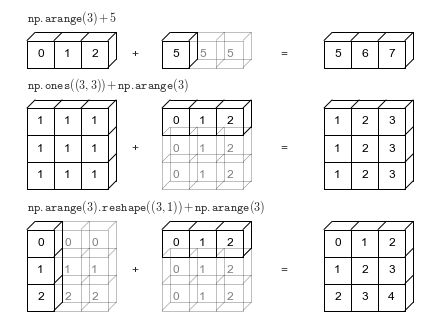

In [9]:
# ==========================================
# 📡 BROADCASTING EXAMPLES
# ==========================================

# 1. Broadcasting a 1D array across a 2D Matrix
a = np.arange(12).reshape(3, 4)  # Shape: (3, 4)
b = np.arange(4)                 # Shape: (4,)
print("3x4 Matrix + 1D Array:\n", a + b)

# 2. Broadcasting a Column Vector and a Row Vector
a = np.arange(3).reshape(1, 3)   # Row Vector (1, 3)
b = np.arange(4).reshape(4, 1)   # Column Vector (4, 1)
# Both arrays stretch! 'a' duplicates downwards, 'b' duplicates rightwards.
print("\nRow (1,3) + Column (4,1) -> 4x3 Matrix:\n", a + b)

# 3. Scalar Broadcasting
a = np.array([100])              # Shape (1,)
b = np.arange(4).reshape(2, 2)   # Shape (2,2)
print("\nScalar + 2x2 Matrix:\n", a + b)

3x4 Matrix + 1D Array:
 [[ 0  2  4  6]
 [ 4  6  8 10]
 [ 8 10 12 14]]

Row (1,3) + Column (4,1) -> 4x3 Matrix:
 [[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]

Scalar + 2x2 Matrix:
 [[100 101]
 [102 103]]


In [ ]:
# ==========================================
# 💻 EXAMPLE: Broadcasting
# ==========================================

# Mini Challenge Solution: 10x10 Multiplication Table
row = np.arange(1, 11).reshape(10, 1) # Shape (10, 1)
col = np.arange(1, 11).reshape(1, 10) # Shape (1, 10)

mult_table = row * col
print("📊 10x10 Multiplication Table:\n", mult_table)

# Testing Hard Practice Task 9
a = np.zeros((2, 3, 4))
b = np.zeros((1, 3, 1))
print(f"\n🧠 Hard Task 9 Shape: {(a + b).shape}") # (2, 3, 4)


📊 10x10 Multiplication Table:
 [[  1   2   3   4   5   6   7   8   9  10]
 [  2   4   6   8  10  12  14  16  18  20]
 [  3   6   9  12  15  18  21  24  27  30]
 [  4   8  12  16  20  24  28  32  36  40]
 [  5  10  15  20  25  30  35  40  45  50]
 [  6  12  18  24  30  36  42  48  54  60]
 [  7  14  21  28  35  42  49  56  63  70]
 [  8  16  24  32  40  48  56  64  72  80]
 [  9  18  27  36  45  54  63  72  81  90]
 [ 10  20  30  40  50  60  70  80  90 100]]

🧠 Hard Task 9 Shape: (2, 3, 4)


### 🛠️ Practice Tasks: Concept 3
*Create a new code cell and complete the following:*
1. **Score Normalization:** Create a `(5, 4)` array representing 5 students' scores across 4 subjects for your IITM B.S. degree assignment. Create a 1D array of shape `(4,)` representing the max possible score for each subject. Divide the matrix by the 1D array to find the percentage scores.
2. **Matrix Expansion:** Create a `(6, 1)` column vector of ones. Add a `(1, 5)` row vector of numbers `[1, 2, 3, 4, 5]` to it. Print the resulting `(6, 5)` shape to observe two-way broadcasting in action.

### 🏋️ Practice Tasks (Easy)
Predict the output shape of:
1. `(3, 4) + (4,)`
2. `(5, 3) + (1, 3)`
3. `(10, 2) + (2,)`

### 🏋️ Practice Tasks (Medium)
4. `(5, 4) + (5, 1)`
5. `(3, 1) + (1, 5)`
6. `(4, 1) + (4, 5)`

### 🏋️ Practice Tasks (Hard)
7. `(2, 3, 4) + (4,)`
8. `(2, 3, 4) + (3, 4)`
9. `(2, 3, 4) + (1, 3, 1)`

### 🚀 Mini Challenge
Create a 10x10 multiplication table (from 1 to 10) using **only** broadcasting and `np.arange`. No loops!

### 🎤 Interview Question
**Q:** Does broadcasting create a new array in memory?
**A:** No! Broadcasting is a **virtual** mechanism. NumPy uses the original data in memory and calculates the indices on the fly during the C-level loop. This makes it extremely memory efficient.

### 🌍 Real World Use Case
**Data Normalization:** If you have a dataset of 1000 students and 5 subjects `shape=(1000, 5)`, you can subtract the mean of each subject `shape=(5,)` from the entire dataset in one line: `data - data.mean(axis=0)`. Broadcasting handles the rest!

### 💡 Fun Fact
The concept of broadcasting was inspired by the APL programming language from the 1960s, which used the term "scalar extension" to describe stretching scalars to match arrays.


# 🧮 Concept 4: Mathematical Operations (Sigmoid & MSE)

### 📝 Theory
NumPy allows you to implement complex Machine Learning formulas in a single, vectorized line of code.
1. **Sigmoid Activation Function:** Used in neural networks and logistic regression to squash outputs into probabilities between 0 and 1.

   $$\sigma(x) = \frac{1}{1 + e^{-x}}$$

2. **Mean Squared Error (MSE):** The primary cost function in regression algorithms to measure how far predicted values deviate from actual actuals.

   $$MSE = \frac{1}{n} \sum (y_{true} - y_{pred})^2$$

### 📊 Diagram: Sigmoid Curve
```text
  1.0 |               ___________
      |            /
  0.5 |----------* (0, 0.5)
      |        /
  0.0 |_______/
      -------------------------
         -5    0    5
```

### ⚠️ Common Mistake
**Overflow in Sigmoid:** If `x` is a large negative number (e.g., -1000), `-x` becomes 1000. `np.exp(1000)` exceeds floating-point limits and results in `inf`. `1 / (1 + inf)` evaluates to `0.0`, which is mathematically correct but throws a `RuntimeWarning`. Fix: Clip inputs or use `scipy.special.expit`.



In [5]:
# ==========================================
# 💻 EXAMPLE: ML Math Functions
# ==========================================

# Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Mini Challenge Solution: Neural Net Layer
W = np.random.randn(3, 4) # 3 neurons, 4 features
X = np.random.randn(4, 2) # 4 features, 2 samples
b = np.random.randn(3, 1) # 3 neurons

Z = W @ X + b
A = sigmoid(Z)
print("🧠 Neural Net Output Shape:", A.shape)


🧠 Neural Net Output Shape: (3, 2)


In [10]:
# ==========================================
# 🧠 MACHINE LEARNING MATH IN NUMPY
# ==========================================

# --- 1. Sigmoid Function ---
def sigmoid(array):
    return 1 / (1 + np.exp(-array))

a = np.arange(-5, 6)
print("Sigmoid Output (squashed to 0-1):\n", np.round(sigmoid(a), 3))

# --- 2. Mean Squared Error (MSE) ---
np.random.seed(1)
actual = np.random.randint(1, 50, 5)
predicted = np.random.randint(1, 50, 5)

def mse(y_true, y_pred):
    # Notice how cleanly the Python code maps to the mathematical LaTeX formula
    return np.mean((y_true - y_pred)**2)

print("\nActuals:", actual)
print("Predicted:", predicted)
print("Mean Squared Error:", mse(actual, predicted))

Sigmoid Output (squashed to 0-1):
 [0.007 0.018 0.047 0.119 0.269 0.5   0.731 0.881 0.953 0.982 0.993]

Actuals: [38 44 13  9 10]
Predicted: [12  6 16  1 17]
Mean Squared Error: 448.4


### 🛠️ Practice Tasks: Concept 4
*Create a new code cell and complete the following:*
1. **Implement ReLU:** The Rectified Linear Unit (ReLU) is the most common activation function in deep learning. Implement it to convert any negative number in a random array to 0, leaving positive numbers unchanged. *(Hint: Use `np.maximum(0, array)`)*.
2. **Zorvyn Analytics Simulation:** Write a function to calculate **Mean Absolute Error (MAE)**. Generate two arrays of 100 random numbers (simulating actual vs predicted daily active users). Calculate the MAE using `np.abs()`.

### 🏋️ Practice Tasks (Easy)
1. Implement the **ReLU** function: $f(x) = \max(0, x)$.
2. Calculate the MSE for `actual = [10, 20, 30]` and `predicted = [12, 18, 33]`.
3. Compute the derivative of Sigmoid: $\sigma'(x) = \sigma(x)(1 - \sigma(x))$ for `x = 0`.

### 🏋️ Practice Tasks (Medium)
4. Implement **Mean Absolute Error (MAE)**: $\frac{1}{n} \sum |y_{true} - y_{pred}|$.
5. Implement **Binary Cross Entropy (BCE)**: $-\frac{1}{n} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$. *(Hint: use `np.clip` to avoid `log(0)`)*.
6. Write a vectorized function to calculate the **Softmax** of an array.

### 🏋️ Practice Tasks (Hard)
7. Implement the **R² Score** (Coefficient of Determination): $1 - \frac{SS_{res}}{SS_{tot}}$.
8. Implement **One-Hot Encoding** for an array of class labels `[0, 2, 1, 2, 0]` using `np.eye()`.
9. Write a function that calculates the **Cosine Similarity** between two 1D vectors.

### 🚀 Mini Challenge
Implement the forward pass of a single neural network layer: $Z = W \cdot X + b$, followed by $A = \text{Sigmoid}(Z)$. Use random matrices for $W$, $X$, and $b$.

### 🎤 Interview Question
**Q:** Why is Sigmoid rarely used in the hidden layers of modern Deep Neural Networks?
**A:** Because of the **Vanishing Gradient Problem**. For large positive or negative inputs, the sigmoid curve is flat, meaning its derivative is close to 0. During backpropagation, gradients shrink exponentially, halting learning. This is why **ReLU** is preferred today.

### 🌍 Real World Use Case
MSE is the default loss function for **Regression tasks** (e.g., predicting house prices). BCE is the default for **Binary Classification** (e.g., spam vs. not spam). Both are implemented in NumPy in a single line!

### 💡 Fun Fact
The `@` operator for matrix multiplication was added to Python 3.5 specifically because the NumPy community lobbied for it to make code like `W @ X + b` cleaner!


# 🔧 Concept 5: Working with Missing Values (np.nan)

Real-world datasets are notoriously messy. NumPy represents missing numerical data as `np.nan` (Not a Number).

Because `np.nan` acts like a black hole (any math operation involving `nan` results in `nan`), detecting and filtering them out using `np.isnan()` is a mandatory data preprocessing step.

### 📊 Diagram: The NaN Virus
```text
[ 1, 2, np.nan, 4 ]
       ↓ sum()
[ nan ]  <-- The whole sum is destroyed!

       ↓ np.nansum()
[ 7 ]    <-- Safely ignores the virus!
```

### ⚠️ Common Mistake
Trying to find NaNs using `arr == np.nan`. 
Because `np.nan` is defined by the IEEE 754 standard as "undefined", **NaN is never equal to itself!** `np.nan == np.nan` evaluates to `False`. You **must** use `np.isnan(arr)`.



In [6]:
# ==========================================
# 💻 EXAMPLE: Missing Values
# ==========================================
arr = np.array([10, np.nan, 30, np.nan, 50])

# Easy Task 1 & 2
nan_count = np.sum(np.isnan(arr))
clean_arr = arr[~np.isnan(arr)]

print(f"🦠 NaN Count: {nan_count}")
print(f"🧼 Clean Array: {clean_arr}")

# Medium Task 5: Replace with mean
arr_filled = np.where(np.isnan(arr), np.nanmean(arr), arr)
print(f"🩹 Filled with Mean: {arr_filled}")


🦠 NaN Count: 2
🧼 Clean Array: [10. 30. 50.]
🩹 Filled with Mean: [10. 30. 30. 30. 50.]


In [11]:
import warnings
warnings.filterwarnings('ignore') # Hides runtime warnings when math hits NaNs

# ==========================================
# 🕵️ HANDLING MISSING VALUES (NaN)
# ==========================================
a = np.array([1, 2, 3, 4, np.nan, 6])
print("Original Array with NaN:", a)

# Standard mathematical functions break if NaN is present
print("Mean with NaN present:", np.mean(a)) # Outputs 'nan'

# How to filter out NaNs using Boolean Indexing & ~ (NOT) operator
clean_array = a[~np.isnan(a)]
print("Cleaned Array:", clean_array)
print("Mean of Cleaned Array:", np.mean(clean_array))

# Alternatively, use NumPy's built-in NaN-safe functions
print("Safe Mean using np.nanmean():", np.nanmean(a))

Original Array with NaN: [ 1.  2.  3.  4. nan  6.]
Mean with NaN present: nan
Cleaned Array: [1. 2. 3. 4. 6.]
Mean of Cleaned Array: 3.2
Safe Mean using np.nanmean(): 3.2


### 🛠️ Practice Tasks: Concept 5
*Create a new code cell and complete the following:*
1. **NaN Injection:** Create an array of 20 random floats. Manually inject `np.nan` into indices 3, 7, and 14. 
2. **Imputation:** Instead of deleting the NaNs, replace them with the number `0`. *(Hint: generate a boolean mask using `np.isnan()`, and use it to reassign values in the array)*.

### 🏋️ Practice Tasks (Easy)
Given `arr = np.array([10, np.nan, 30, np.nan, 50])`:
1. Count how many `NaN` values are in the array.
2. Remove all `NaN` values to get a clean 1D array.
3. Calculate the mean of the clean array.

### 🏋️ Practice Tasks (Medium)
4. Replace all `NaN` values with `0`.
5. Replace all `NaN` values with the **mean** of the non-NaN values.
6. Given a 2D array, find the mean of each **column** ignoring NaNs.

### 🏋️ Practice Tasks (Hard)
7. Implement **Forward Fill**: Replace each `NaN` with the last valid observation (e.g., `[1, nan, nan, 4]` -> `[1, 1, 1, 4]`).
8. Implement **Interpolation**: Replace each `NaN` with the average of its immediate left and right neighbors.
9. Drop any **row** from a 2D array that contains at least one `NaN`.

### 🚀 Mini Challenge
Write a function that takes a 2D array and returns the **percentage of missing data** in each column.

### 🎤 Interview Question
**Q:** What is the difference between `np.mean()` and `np.nanmean()`?
**A:** `np.mean()` will return `nan` if even a single element in the array is `nan`. `np.nanmean()` automatically filters out `nan` values and calculates the mean of the remaining valid numbers.

### 🌍 Real World Use Case
When dealing with sensor data (e.g., temperature readings), sensors often fail and transmit `NaN`. Using `np.nanmean()` allows you to calculate the daily average temperature without the entire day's data being ruined by a 5-minute sensor outage.

### 💡 Fun Fact
`np.nan` is of type `float`. You cannot have `np.nan` in an integer array! If you try to insert `np.nan` into an `int` array, NumPy will silently upcast the entire array to `float64`.


# 📈 Concept 6: Plotting Graphs & Meshgrids


NumPy generates the mathematical data, and Matplotlib visualizes it. 
- Use `np.linspace()` to generate smooth X-axis values, perform a vectorized math operation to generate our Y-axis values, and plot the result.
- Use **Meshgrids** (`np.meshgrid`) to create 2D coordinate matrices from 1D arrays, which is essential for plotting 3D surfaces and contour maps.

### 📊 Diagram: Meshgrid Logic
```text
x = [1, 2, 3]
y = [4, 5]

X, Y = np.meshgrid(x, y)

X (X-coords):    Y (Y-coords):
[[1, 2, 3],      [[4, 4, 4],
 [1, 2, 3]]       [5, 5, 5]]
```

### ⚠️ Common Mistake
Using `np.arange()` instead of `np.linspace()` for plotting continuous functions like `sin(x)`. `arange` with float steps can suffer from floating-point precision issues and might miss the exact endpoint, resulting in jagged or incomplete plots. Always use `linspace(start, stop, num_points)`.


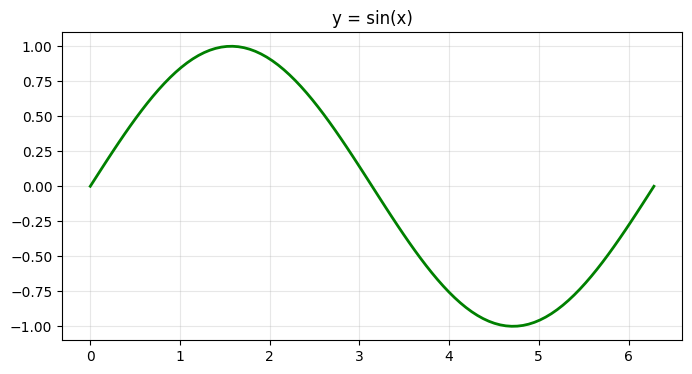

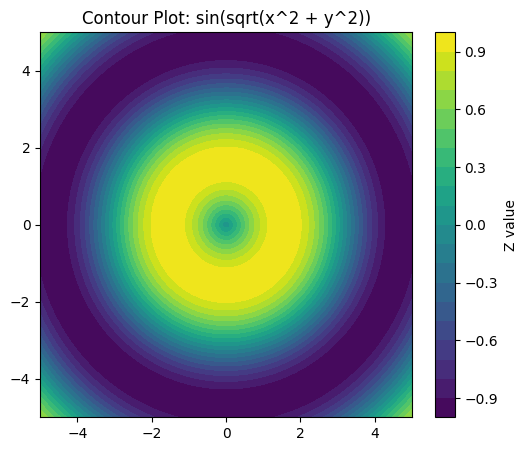

In [7]:
# ==========================================
# 💻 EXAMPLE: Plotting & Meshgrids
# ==========================================
import matplotlib.pyplot as plt

# Easy Task 3: Sine Wave
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, 'g-', linewidth=2)
plt.title('y = sin(x)')
plt.grid(True, alpha=0.3)
plt.show()

# Hard Task 8: Contour Plot using Meshgrid
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(label='Z value')
plt.title('Contour Plot: sin(sqrt(x^2 + y^2))')
plt.show()


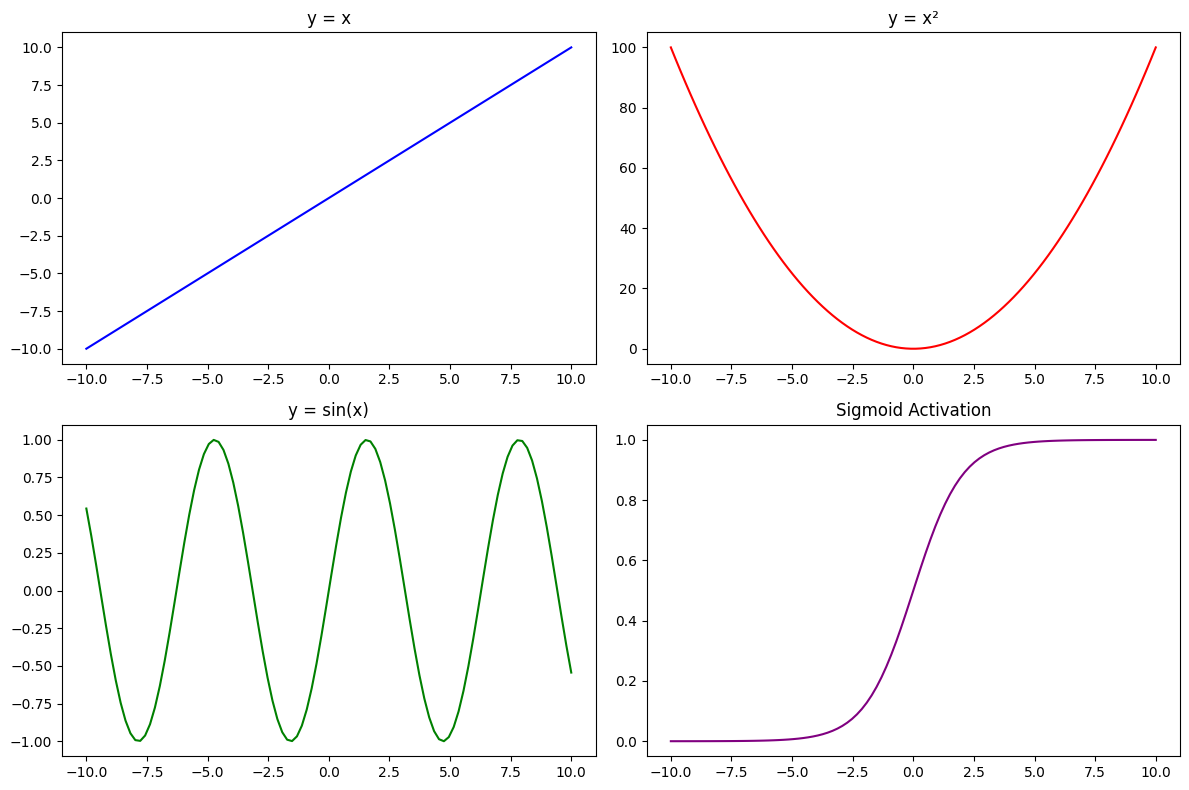

In [12]:
import matplotlib.pyplot as plt

# ==========================================
# 📈 PLOTTING MATH FUNCTIONS
# ==========================================
# Generate 100 evenly spaced points between -10 and 10
x = np.linspace(-10, 10, 100)

plt.figure(figsize=(12, 8))

# 1. Linear: y = x
plt.subplot(2, 2, 1)
plt.plot(x, x, color='blue')
plt.title('y = x')

# 2. Quadratic (Parabola): y = x^2
plt.subplot(2, 2, 2)
plt.plot(x, x**2, color='red')
plt.title('y = x²')

# 3. Trigonometric: y = sin(x)
plt.subplot(2, 2, 3)
plt.plot(x, np.sin(x), color='green')
plt.title('y = sin(x)')

# 4. Sigmoid Function
plt.subplot(2, 2, 4)
plt.plot(x, 1 / (1 + np.exp(-x)), color='purple')
plt.title('Sigmoid Activation')

plt.tight_layout()
plt.show()

### 🛠️ Practice Tasks: Concept 6
*Create a new code cell and complete the following:*
1. **Plot the Tanh Curve:** Generate an X-axis using `np.linspace` from -5 to 5. Plot the hyperbolic tangent function using `np.tanh(x)`. Add a title and grid.
2. **Meshgrid Basics:** Create an array `x = [0, 1, 2]` and `y = [0, 1, 2]`. Pass them into `np.meshgrid(x, y)` to unpack two matrices `X` and `Y`. Print both to observe how the coordinate grid is constructed.

### 🏋️ Practice Tasks (Easy)
1. Plot the linear function $y = x$ from -10 to 10.
2. Plot the quadratic function $y = x^2$ from -5 to 5.
3. Plot $y = \sin(x)$ from $0$ to $2\pi$.

### 🏋️ Practice Tasks (Medium)
4. Plot $y = e^x$ and $y = \ln(x)$ on the **same graph** with a legend.
5. Create a scatter plot of 100 random $(x, y)$ points and color them based on whether $y > x$.
6. Plot the Sigmoid function and draw a horizontal dashed line at $y = 0.5$.

### 🏋️ Practice Tasks (Hard)
7. Create a 2x2 subplot grid showing: $\sin(x)$, $\cos(x)$, $\tan(x)$, and $\text{Sigmoid}(x)$.
8. Use `np.meshgrid` to evaluate $Z = \sin(\sqrt{X^2 + Y^2})$ and plot it as a **Contour Plot**.
9. Plot the 3D surface of the "Mexican Hat" function: $Z = \frac{\sin(R)}{R}$ where $R = \sqrt{X^2 + Y^2}$.

### 🚀 Mini Challenge
Plot the **Decision Boundary** of a simple neural network: Create a meshgrid from -5 to 5, calculate $Z = \text{Sigmoid}(X + Y)$, and plot it as a heatmap using `plt.imshow()`.



### 🎤 Interview Question

# 🎤 Interview Corner: Test Your Knowledge

**Q1: What exactly happens in CPU memory during "Vectorization" that makes NumPy so fast?**
> **Answer:** Vectorization allows NumPy to push loop execution down to pre-compiled C-code, avoiding Python's interpreter overhead. It utilizes the CPU's SIMD (Single Instruction, Multiple Data) architecture, applying one mathematical operation to a contiguous block of homogeneous memory all at once, rather than fetching and checking types for one item at a time.

**Q2: What is the difference between Fancy Indexing and Slicing regarding memory?**
> **Answer:** Slicing an array (e.g., `arr[1:4]`) returns a **view** of the original memory, meaning modifications affect the source data. Fancy Indexing (e.g., `arr[[1, 3, 4]]`) returns a completely new **copy** of the data in memory.

**Q3: Explain Broadcasting Rules in plain language.**
> **Answer:** Broadcasting stretches smaller arrays to match larger ones for arithmetic. It works right-to-left across dimensions. If dimensions don't match, NumPy pads the smaller shape with 1s on the left. Then, any dimension with a size of exactly `1` is virtually duplicated to match the other array's size.

**Q4: If a dataset contains `np.nan`, what happens to `np.sum()`? What is the workaround?**
> **Answer:** The sum operation will be mathematically contaminated and return `nan`. The workaround is to either filter out the NaNs using boolean indexing (`arr[~np.isnan(arr)]`) or utilize NumPy's built-in NaN-safe functions like `np.nansum()`.


**Q5:** Why do we use `np.meshgrid` in Machine Learning?
**Answer:** Meshgrid is used to evaluate a function over a 2D space. In ML, it is heavily used to plot **Decision Boundaries** for classification algorithms (like SVM or Logistic Regression) and to visualize **Loss Landscapes** (contour plots) during gradient descent optimization.

### 🌍 Real World Use Case
In Geographic Information Systems (GIS), meshgrids are used to map elevation data (Z) over latitude (X) and longitude (Y) to generate 3D topographical maps and calculate slopes for construction planning.

### 💡 Fun Fact
The "Mexican Hat" wavelet (plotted in Hard Task 9) is actually used in real-life signal processing and particle physics to detect edges and anomalies in data!


# 🏆 Final Recap & Next Steps

You have now mastered the advanced foundations of NumPy! 

### 📚 Checklist:
✅ **Performance:** Proved why NumPy beats Python lists.
✅ **Indexing:** Mastered Fancy and Boolean masking.
✅ **Broadcasting:** Understood the 2 rules of shape alignment.
✅ **Math:** Implemented Sigmoid, MSE, and ReLU from scratch.
✅ **Data Cleaning:** Handled the `np.nan` virus safely.
✅ **Visualization:** Plotted functions and 2D/3D Meshgrids.

### 🚀 What's Next? (NumPy Part 3)
- **Linear Algebra:** `np.linalg.inv`, `np.linalg.eig`, SVD.
- **Random Sampling:** `np.random.choice`, distributions, seeds.
- **File I/O:** `np.save`, `np.load`, `np.savetxt`.
- **Advanced Broadcasting:** `np.newaxis` and `np.expand_dims`.

💡 **Pro Tip:** Try to implement **Linear Regression from scratch** using only NumPy (using the MSE and Gradient Descent concepts you learned today). If you can do that, you are ready for Pandas and Scikit-Learn!
